# 📊 Data Exploration and Visualization

## Document Type Classification - Part 1

**Goal**: Explore and visualize the dataset to understand:
- Dataset structure and distribution
- Visual differences between document types
- Image properties (dimensions, formats)
- Initial insights for model development

**Dataset**: 2,100 real identity documents (700 per type)
- 🛂 Passports (Greece)
- 🪪 ID Cards (Russia)
- 🚗 Driver's Licenses (USA - West Virginia)


## 1. Setup and Imports


In [1]:
# Data handling
import pandas as pd
import numpy as np
from pathlib import Path
import os

# Image processing
from PIL import Image
import cv2

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Display settings
%matplotlib inline
pd.set_option('display.max_columns', None)

print('✅ All libraries imported successfully!')


✅ All libraries imported successfully!


## 2. Load Datasets


In [2]:
# Define paths
DATA_DIR = '../../datasets/idnet/document_type_classification/data/'

# Load all splits
train_df = pd.read_csv(DATA_DIR + 'train_dataset.csv')
val_df = pd.read_csv(DATA_DIR + 'val_dataset.csv')
test_df = pd.read_csv(DATA_DIR + 'test_dataset.csv')
full_df = pd.read_csv(DATA_DIR + 'full_dataset.csv')

print('📂 Datasets loaded successfully!')
print(f'\n📊 Dataset sizes:')
print(f'   Train:      {len(train_df):,} images')
print(f'   Validation: {len(val_df):,} images')
print(f'   Test:       {len(test_df):,} images')
print(f'   Total:      {len(full_df):,} images')

print(f'\n📋 Columns: {list(full_df.columns)}')


📂 Datasets loaded successfully!

📊 Dataset sizes:
   Train:      1,470 images
   Validation: 315 images
   Test:       315 images
   Total:      2,100 images

📋 Columns: ['image_path', 'document_type']


## 3. Dataset Statistics


In [6]:
# Overall distribution
print('📊 OVERALL CLASS DISTRIBUTION')
print('=' * 60)

class_counts = full_df['document_type'].value_counts()
for doc_type, count in class_counts.items():
    pct = (count / len(full_df)) * 100
    print(f'{doc_type:15s}: {count:4d} images ({pct:.1f}%)')

print(f'\nTotal: {len(full_df):,} images')
print('=' * 60)


📊 OVERALL CLASS DISTRIBUTION
passport       :  700 images (33.3%)
id_card        :  700 images (33.3%)
driver_license :  700 images (33.3%)

Total: 2,100 images


## 3.1. Train Set Distribution


In [7]:
print('🎓 TRAIN SET')
print('=' * 60)
print(f'Total: {len(train_df):,} images (70% of dataset)')
print('-' * 60)

for doc_type in ['passport', 'id_card', 'driver_license']:
    count = (train_df['document_type'] == doc_type).sum()
    pct = (count / len(train_df)) * 100
    print(f'  {doc_type:15s}: {count:3d} images ({pct:.1f}%)')

print('=' * 60)


🎓 TRAIN SET
Total: 1,470 images (70% of dataset)
------------------------------------------------------------
  passport       : 490 images (33.3%)
  id_card        : 490 images (33.3%)
  driver_license : 490 images (33.3%)


## 3.2. Validation Set Distribution


In [8]:
print('🔍 VALIDATION SET')
print('=' * 60)
print(f'Total: {len(val_df):,} images (15% of dataset)')
print('-' * 60)

for doc_type in ['passport', 'id_card', 'driver_license']:
    count = (val_df['document_type'] == doc_type).sum()
    pct = (count / len(val_df)) * 100
    print(f'  {doc_type:15s}: {count:3d} images ({pct:.1f}%)')

print('=' * 60)


🔍 VALIDATION SET
Total: 315 images (15% of dataset)
------------------------------------------------------------
  passport       : 105 images (33.3%)
  id_card        : 105 images (33.3%)
  driver_license : 105 images (33.3%)


## 3.3. Test Set Distribution


In [9]:
print('🧪 TEST SET')
print('=' * 60)
print(f'Total: {len(test_df):,} images (15% of dataset)')
print('-' * 60)

for doc_type in ['passport', 'id_card', 'driver_license']:
    count = (test_df['document_type'] == doc_type).sum()
    pct = (count / len(test_df)) * 100
    print(f'  {doc_type:15s}: {count:3d} images ({pct:.1f}%)')

print('=' * 60)
print('\n✅ Perfect stratification: Each split maintains 33.3% per class')


🧪 TEST SET
Total: 315 images (15% of dataset)
------------------------------------------------------------
  passport       : 105 images (33.3%)
  id_card        : 105 images (33.3%)
  driver_license : 105 images (33.3%)

✅ Perfect stratification: Each split maintains 33.3% per class


## 4. Visualize Class Distribution


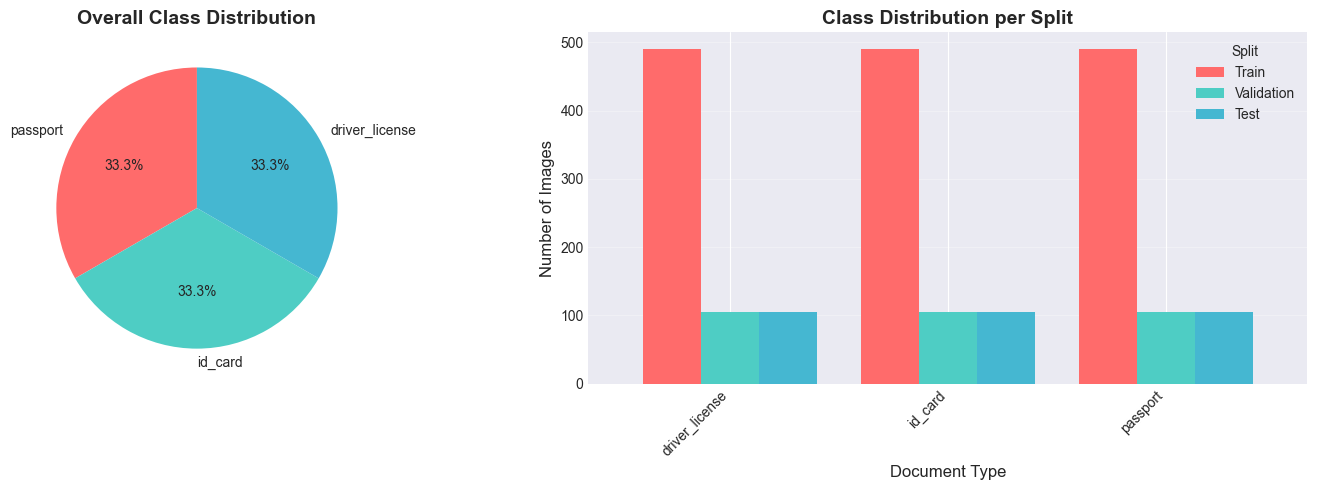

✅ Balanced dataset - each class has equal representation!


In [10]:
# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Pie chart
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
full_df['document_type'].value_counts().plot(
    kind='pie',
    ax=axes[0],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)
axes[0].set_title('Overall Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('')

# Bar chart - per split
split_data = pd.DataFrame({
    'Train': train_df['document_type'].value_counts(),
    'Validation': val_df['document_type'].value_counts(),
    'Test': test_df['document_type'].value_counts()
})

split_data.plot(kind='bar', ax=axes[1], color=colors, width=0.8)
axes[1].set_title('Class Distribution per Split', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Document Type', fontsize=12)
axes[1].set_ylabel('Number of Images', fontsize=12)
axes[1].legend(title='Split', fontsize=10)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('✅ Balanced dataset - each class has equal representation!')


## 5. Sample Images from Each Class


In [11]:
# Select 3 random samples from each class
np.random.seed(42)

samples = {}
for doc_type in ['passport', 'id_card', 'driver_license']:
    samples[doc_type] = train_df[train_df['document_type'] == doc_type].sample(3, random_state=42)

print('📸 Selected sample images:')
for doc_type, df in samples.items():
    print(f'\n{doc_type.upper()}:')
    for idx, row in df.iterrows():
        print(f'   - {os.path.basename(row["image_path"])}')


📸 Selected sample images:

PASSPORT:
   - generated.photos_v3_0212155.png
   - generated.photos_v3_0406347.png
   - generated.photos_v3_0615397.png

ID_CARD:
   - generated.photos_v3_0230254.png
   - generated.photos_v3_0877914.png
   - generated.photos_v3_0260893.png

DRIVER_LICENSE:
   - generated.photos_v3_0851899.png
   - generated.photos_v3_0929102.png
   - generated.photos_v3_0315148.png


## 6. Display Sample Images (3x3 Grid)


/var/folders/7v/16zlk2l53qq1v3dqsttk28zh0000gn/T/ipykernel_20880/1265426413.py:25: UserWarning: Glyph 128706 (\N{PASSPORT CONTROL}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7v/16zlk2l53qq1v3dqsttk28zh0000gn/T/ipykernel_20880/1265426413.py:25: UserWarning: Glyph 129706 (\N{IDENTIFICATION CARD}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7v/16zlk2l53qq1v3dqsttk28zh0000gn/T/ipykernel_20880/1265426413.py:25: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) Arial.
  plt.tight_layout()
/Users/roy-siftt/final-project/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128706 (\N{PASSPORT CONTROL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/roy-siftt/final-project/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129706 (\N{IDENTIFICATION CARD}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/roy-siftt/final-pr

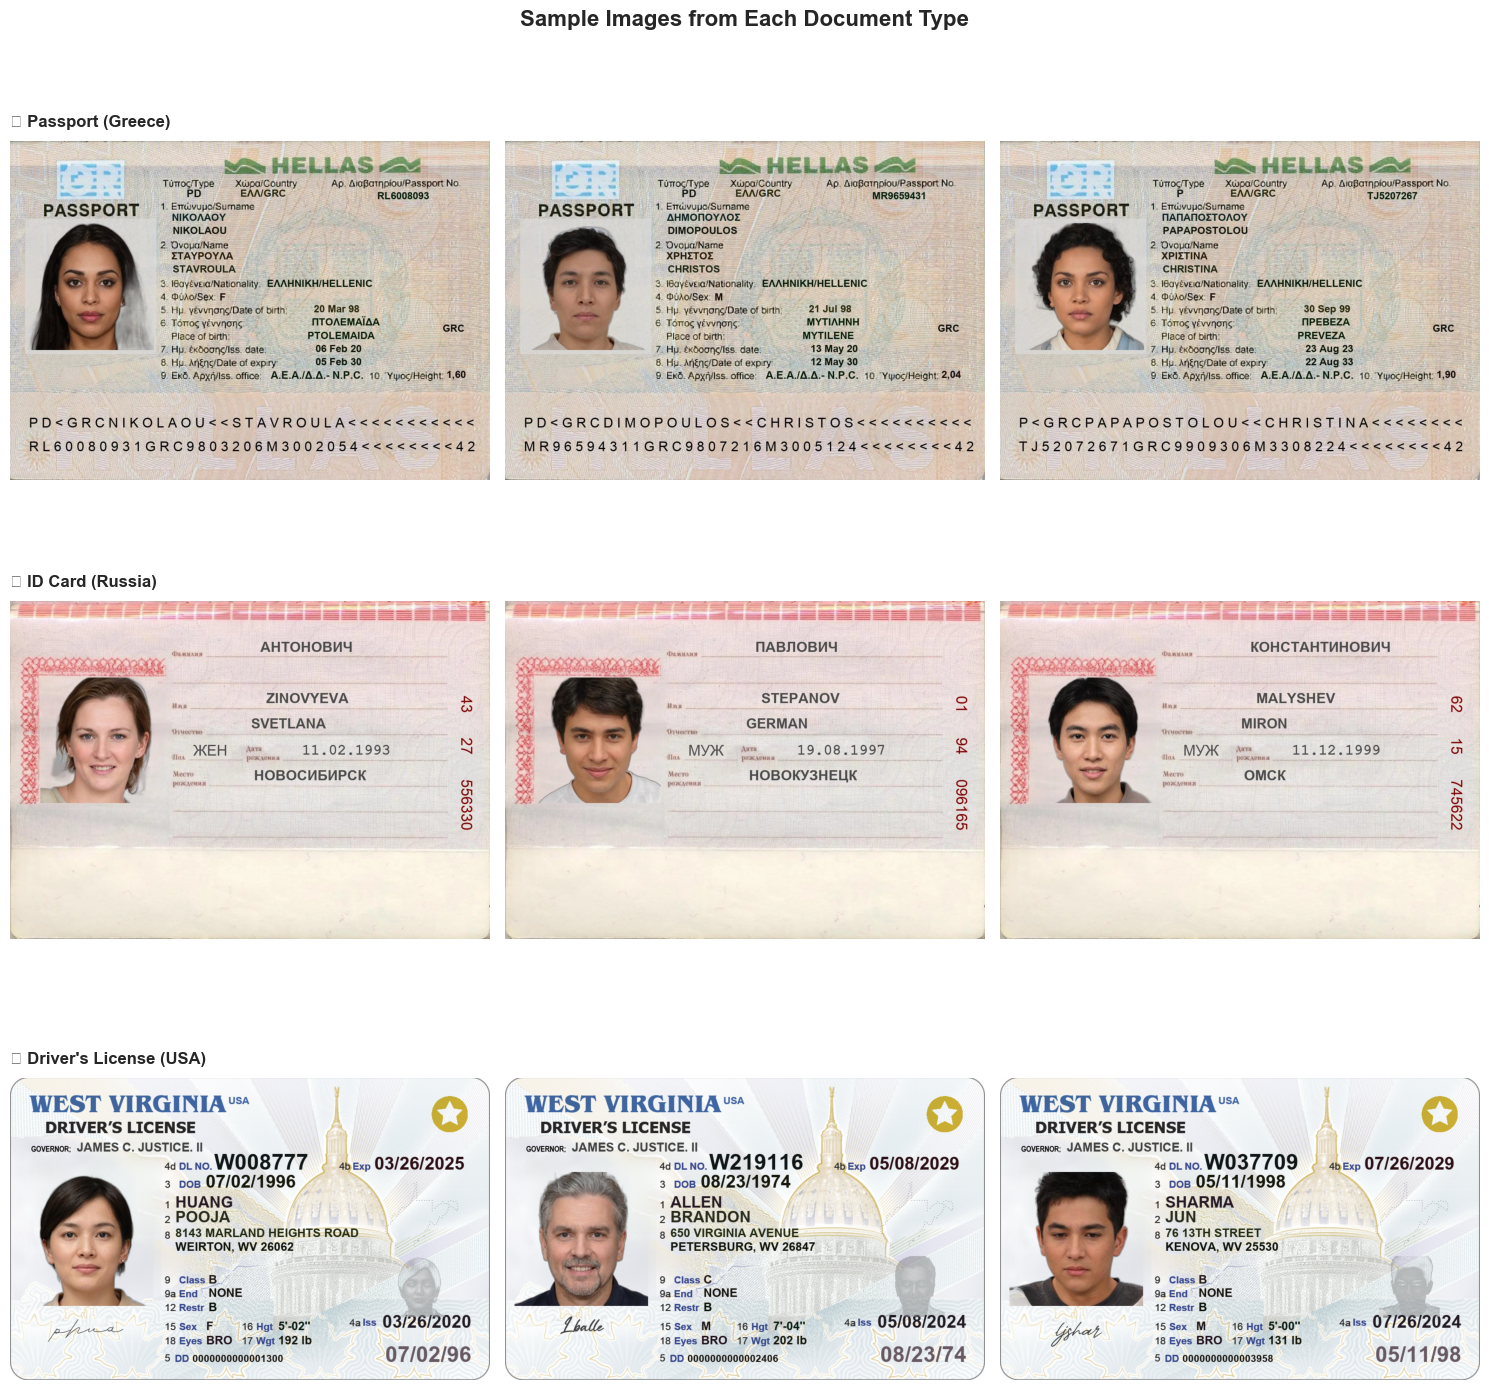

✅ Sample images displayed successfully!


In [12]:
# Create 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
fig.suptitle('Sample Images from Each Document Type', fontsize=16, fontweight='bold', y=0.995)

doc_types = ['passport', 'id_card', 'driver_license']
doc_labels = ['🛂 Passport (Greece)', '🪪 ID Card (Russia)', '🚗 Driver\'s License (USA)']

for row_idx, (doc_type, label) in enumerate(zip(doc_types, doc_labels)):
    sample_images = samples[doc_type]
    
    for col_idx, (_, img_row) in enumerate(sample_images.iterrows()):
        # Load image
        img_path = img_row['image_path']
        img = Image.open(img_path)
        
        # Display
        ax = axes[row_idx, col_idx]
        ax.imshow(img)
        ax.axis('off')
        
        # Add title to first column
        if col_idx == 0:
            ax.set_title(label, fontsize=12, fontweight='bold', loc='left', pad=10)

plt.tight_layout()
plt.show()

print('✅ Sample images displayed successfully!')


## 7. Analyze Image Dimensions


In [13]:
# Analyze dimensions for a sample of images
print('🔍 Analyzing image dimensions...')
print('=' * 50)

dimensions = {'passport': [], 'id_card': [], 'driver_license': []}

# Sample 50 images from each class for analysis
for doc_type in ['passport', 'id_card', 'driver_license']:
    sample_paths = train_df[train_df['document_type'] == doc_type].sample(50, random_state=42)['image_path']
    
    for path in sample_paths:
        img = Image.open(path)
        dimensions[doc_type].append(img.size)  # (width, height)

# Display statistics
for doc_type, dims in dimensions.items():
    widths = [d[0] for d in dims]
    heights = [d[1] for d in dims]
    
    print(f'\n{doc_type.upper()}:')
    print(f'   Width:  min={min(widths)}, max={max(widths)}, avg={np.mean(widths):.0f}')
    print(f'   Height: min={min(heights)}, max={max(heights)}, avg={np.mean(heights):.0f}')
    print(f'   Aspect Ratio: {np.mean(widths)/np.mean(heights):.2f}')

print('\n💡 Recommendation: Resize all images to 224x224 (standard for pre-trained models)')


🔍 Analyzing image dimensions...

PASSPORT:
   Width:  min=1136, max=1136, avg=1136
   Height: min=803, max=803, avg=803
   Aspect Ratio: 1.41

ID_CARD:
   Width:  min=1519, max=1519, avg=1519
   Height: min=1069, max=1069, avg=1069
   Aspect Ratio: 1.42

DRIVER_LICENSE:
   Width:  min=1013, max=1013, avg=1013
   Height: min=638, max=638, avg=638
   Aspect Ratio: 1.59

💡 Recommendation: Resize all images to 224x224 (standard for pre-trained models)


## 8. Visualize Image Dimensions Distribution


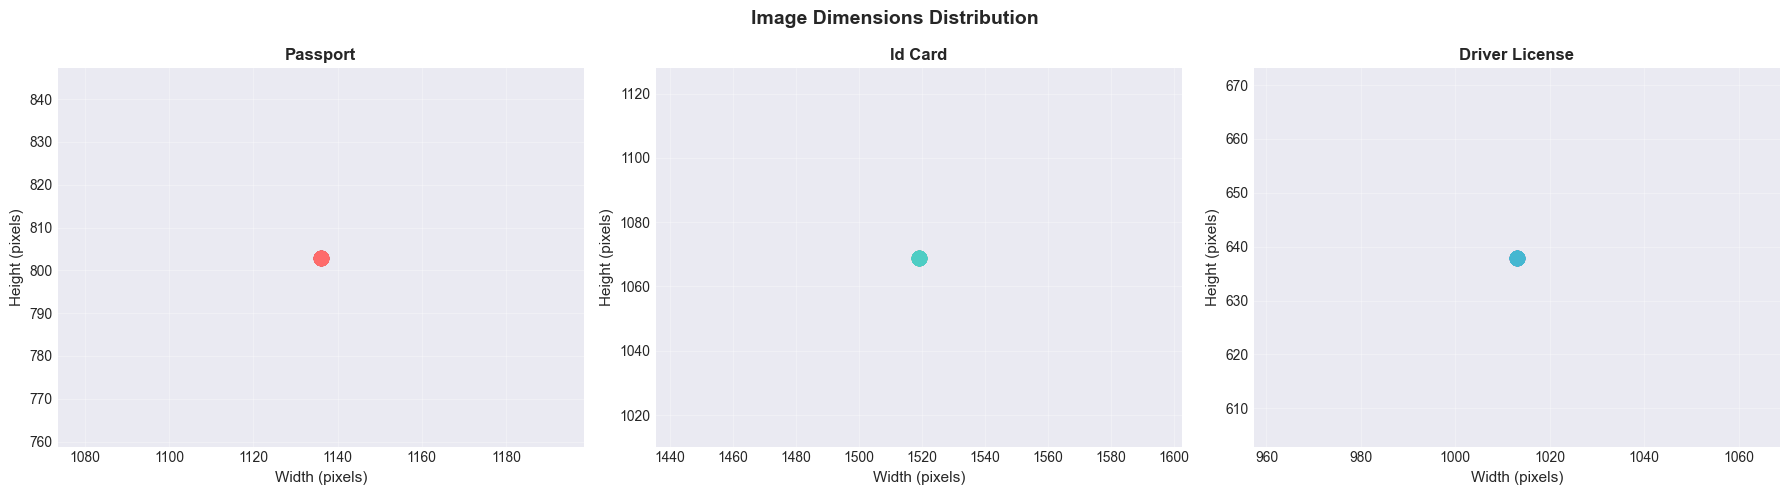

In [14]:
# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (doc_type, dims) in enumerate(dimensions.items()):
    widths = [d[0] for d in dims]
    heights = [d[1] for d in dims]
    
    ax = axes[idx]
    ax.scatter(widths, heights, alpha=0.6, s=100, color=colors[idx])
    ax.set_xlabel('Width (pixels)', fontsize=11)
    ax.set_ylabel('Height (pixels)', fontsize=11)
    ax.set_title(f'{doc_type.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('Image Dimensions Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 9. Visual Comparison - Key Differences


/var/folders/7v/16zlk2l53qq1v3dqsttk28zh0000gn/T/ipykernel_20880/1153444203.py:14: UserWarning: Glyph 128706 (\N{PASSPORT CONTROL}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7v/16zlk2l53qq1v3dqsttk28zh0000gn/T/ipykernel_20880/1153444203.py:14: UserWarning: Glyph 129706 (\N{IDENTIFICATION CARD}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/7v/16zlk2l53qq1v3dqsttk28zh0000gn/T/ipykernel_20880/1153444203.py:14: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) Arial.
  plt.tight_layout()


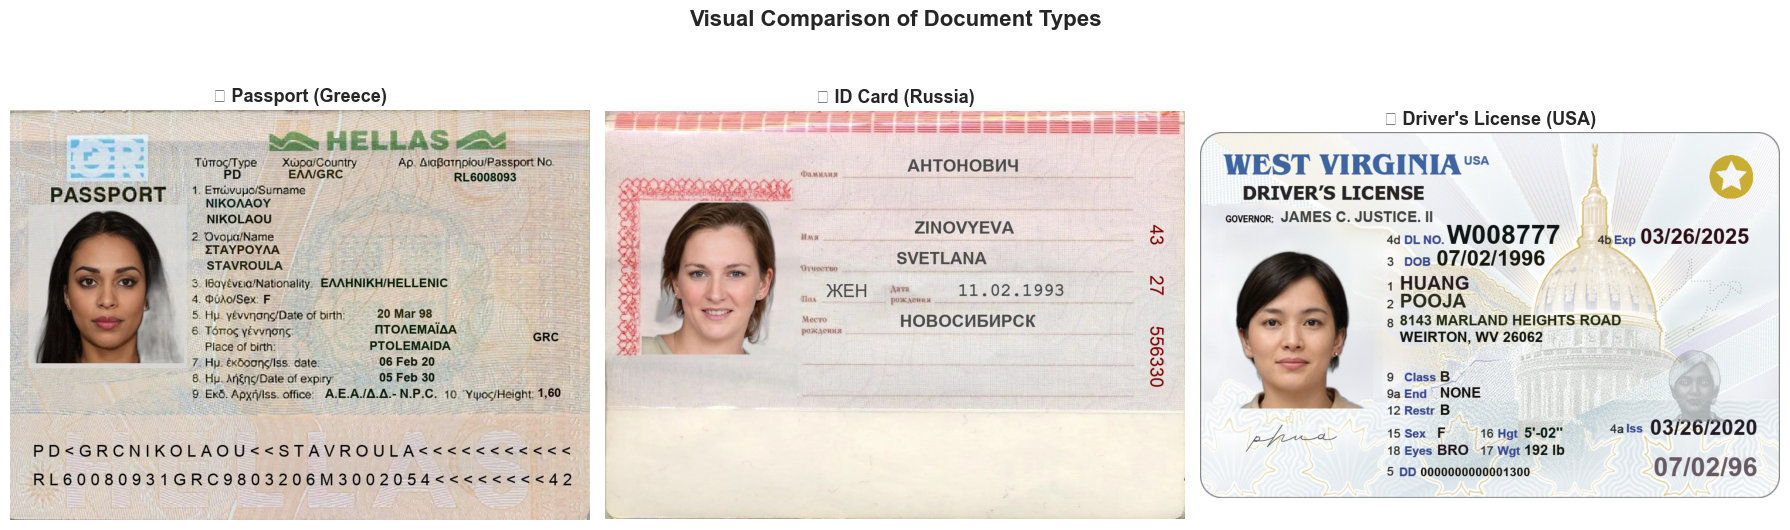


🔍 Key Visual Differences:

🛂 Passports:
   • International standard format
   • Multiple languages (Greek + English)
   • Country emblem at top
   • Larger photo
   • Horizontal layout

🪪 ID Cards:
   • Compact credit-card size
   • Cyrillic script
   • Dense information layout
   • Smaller photo
   • National format

🚗 Driver's Licenses:
   • Credit-card size
   • English text
   • License categories visible
   • State-specific design
   • Vehicle-related information


In [15]:
# Display one image from each class side by side for comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Visual Comparison of Document Types', fontsize=16, fontweight='bold')

for idx, (doc_type, label) in enumerate(zip(doc_types, doc_labels)):
    # Get first sample
    img_path = samples[doc_type].iloc[0]['image_path']
    img = Image.open(img_path)
    
    axes[idx].imshow(img)
    axes[idx].set_title(label, fontsize=13, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print('\n🔍 Key Visual Differences:')
print('\n🛂 Passports:')
print('   • International standard format')
print('   • Multiple languages (Greek + English)')
print('   • Country emblem at top')
print('   • Larger photo')
print('   • Horizontal layout')

print('\n🪪 ID Cards:')
print('   • Compact credit-card size')
print('   • Cyrillic script')
print('   • Dense information layout')
print('   • Smaller photo')
print('   • National format')

print('\n🚗 Driver\'s Licenses:')
print('   • Credit-card size')
print('   • English text')
print('   • License categories visible')
print('   • State-specific design')
print('   • Vehicle-related information')


## 10. Data Quality Check


In [16]:
print('🔍 Data Quality Checks:')
print('=' * 50)

# Check for missing values
print('\n1. Missing values:')
print(full_df.isnull().sum())

# Check if all image paths exist
print('\n2. Checking if all image files exist...')
missing_files = []
for path in full_df['image_path'].sample(100, random_state=42):  # Check 100 random samples
    if not os.path.exists(path):
        missing_files.append(path)

if len(missing_files) == 0:
    print('   ✅ All sampled image files exist!')
else:
    print(f'   ⚠️  Found {len(missing_files)} missing files')

# Check for duplicates
print('\n3. Checking for duplicate images...')
duplicates = full_df['image_path'].duplicated().sum()
if duplicates == 0:
    print('   ✅ No duplicate images found!')
else:
    print(f'   ⚠️  Found {duplicates} duplicate images')

# Check data leakage between splits
print('\n4. Checking for data leakage between splits...')
train_images = set(train_df['image_path'])
val_images = set(val_df['image_path'])
test_images = set(test_df['image_path'])

train_val_overlap = len(train_images & val_images)
train_test_overlap = len(train_images & test_images)
val_test_overlap = len(val_images & test_images)

if train_val_overlap == 0 and train_test_overlap == 0 and val_test_overlap == 0:
    print('   ✅ No data leakage detected - splits are clean!')
else:
    print(f'   ⚠️  Data leakage detected!')
    print(f'      Train-Val overlap: {train_val_overlap}')
    print(f'      Train-Test overlap: {train_test_overlap}')
    print(f'      Val-Test overlap: {val_test_overlap}')


🔍 Data Quality Checks:

1. Missing values:
image_path       0
document_type    0
dtype: int64

2. Checking if all image files exist...
   ✅ All sampled image files exist!

3. Checking for duplicate images...
   ✅ No duplicate images found!

4. Checking for data leakage between splits...
   ✅ No data leakage detected - splits are clean!


## 11. Summary and Key Insights


In [17]:
print('📋 SUMMARY AND KEY INSIGHTS')
print('=' * 60)

print('\n✅ Dataset Quality:')
print('   • Total images: 2,100 (700 per class)')
print('   • Perfectly balanced: 33.3% per class')
print('   • Clean splits: No data leakage')
print('   • All files exist and accessible')

print('\n🎯 Key Visual Differences:')
print('   • Passports: Larger format, international standard, multiple languages')
print('   • ID Cards: Compact, national format, Cyrillic script')
print('   • Licenses: Similar to ID cards but with vehicle-specific information')

print('\n💡 Recommendations for Model Training:')
print('   1. Resize all images to 224x224 (standard for CNNs)')
print('   2. Use data augmentation (rotation, flip, brightness)')
print('   3. Start with transfer learning (ResNet/EfficientNet)')
print('   4. Focus on layout/structure features, not text content')
print('   5. Monitor validation performance to prevent overfitting')

print('\n🔬 Expected Challenges:')
print('   • ID cards and licenses may look similar (both credit-card size)')
print('   • Different aspect ratios need careful resizing')
print('   • Text in different scripts (Greek, Cyrillic, English)')
print('   • Model must learn structure, not memorize specific text')

print('\n🚀 Next Steps:')
print('   → Proceed to: 02_data_preprocessing_and_augmentation.ipynb')
print('   → Build data pipeline with augmentation')
print('   → Prepare for model training')

print('\n✨ Data exploration completed successfully!')


📋 SUMMARY AND KEY INSIGHTS

✅ Dataset Quality:
   • Total images: 2,100 (700 per class)
   • Perfectly balanced: 33.3% per class
   • Clean splits: No data leakage
   • All files exist and accessible

🎯 Key Visual Differences:
   • Passports: Larger format, international standard, multiple languages
   • ID Cards: Compact, national format, Cyrillic script
   • Licenses: Similar to ID cards but with vehicle-specific information

💡 Recommendations for Model Training:
   1. Resize all images to 224x224 (standard for CNNs)
   2. Use data augmentation (rotation, flip, brightness)
   3. Start with transfer learning (ResNet/EfficientNet)
   4. Focus on layout/structure features, not text content
   5. Monitor validation performance to prevent overfitting

🔬 Expected Challenges:
   • ID cards and licenses may look similar (both credit-card size)
   • Different aspect ratios need careful resizing
   • Text in different scripts (Greek, Cyrillic, English)
   • Model must learn structure, not memo